# Jaime Contrarian — Comparativa con el resto de estrategias

Backtest de `JaimeContrarianStrategy` contra el catálogo actual sobre el universo `jaime.yaml`.

In [82]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import logging
logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(name)s: %(message)s')

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

# 1. Universo y datos

In [83]:
from src.io import IO, YFinanceProvider
from src.domain.asset import PriceHistory

universe = IO().load_universe('jaime')
prices = YFinanceProvider().get_prices(universe.tickers, start='2010-01-01', end='2026-04-07')
history = PriceHistory(universe, prices)

print(f'Universe ({len(universe.tickers)}): {universe.tickers}')
print(f'Period: {history.dates[0].date()} -> {history.dates[-1].date()} ({len(history)} days)')

[*********************100%***********************]  21 of 21 completed
WARNING src.io.provider.base: BOTZ: 1796 missing days (42.8%)
WARNING src.io.provider.base: CIBR: 1496 missing days (35.6%)
WARNING src.io.provider.base: DBA: 111 missing days (2.6%)
WARNING src.io.provider.base: GLD: 111 missing days (2.6%)
WARNING src.io.provider.base: IEF: 111 missing days (2.6%)
WARNING src.io.provider.base: IEMA.L: 93 missing days (2.2%)
WARNING src.io.provider.base: ITB: 111 missing days (2.6%)
WARNING src.io.provider.base: IUSN.DE: 2185 missing days (52.0%)
WARNING src.io.provider.base: IWDA.L: 93 missing days (2.2%)
WARNING src.io.provider.base: LIT: 250 missing days (6.0%)
WARNING src.io.provider.base: SLV: 111 missing days (2.6%)
WARNING src.io.provider.base: SOXX: 111 missing days (2.6%)
WARNING src.io.provider.base: TLT: 111 missing days (2.6%)
WARNING src.io.provider.base: XEON.DE: 70 missing days (1.7%)
WARNING src.io.provider.base: XLE: 111 missing days (2.6%)
WARNING src.io.provider.

Universe (21): ['IWDA.L', 'IEMA.L', 'IUSN.DE', 'XLK', 'XLF', 'XLV', 'XLE', 'XLP', 'XLI', 'XLU', 'SOXX', 'CIBR', 'BOTZ', 'LIT', 'ITB', 'SLV', 'DBA', 'IEF', 'GLD', 'TLT', 'XEON.DE']
Period: 2018-04-26 -> 2026-04-02 (1935 days)


# 2. Estrategias

In [84]:
from src.domain.portfolio import Portfolio
from src.domain import Broker
from src.strategy.buy_and_hold import BuyAndHoldStrategy
from src.strategy.merton import MertonStrategy
from src.strategy.merton_vol import MertonVolStrategy
from src.strategy.merton_mom import MertonMomentumStrategy
from src.strategy.merton_custom import MertonCustomStrategy
from src.strategy.merton_dual_mom import MertonDualMomentumStrategy
from src.strategy.merton_full import MertonFullStrategy
from src.strategy.jaime_contrarian import JaimeContrarianStrategy

from src.models.estimators import (
    JamesSteinMean, LedoitWolfCovariance, RollingSigma, BLOmegaMu,
)

DEFENSIVE = 'XEON.DE'

portfolio = Portfolio(initial_cash=10_000_000, max_leverage=1.0, allow_short=False)
broker = Broker(universe.transaction_costs)

mu_estimator = BLOmegaMu(JamesSteinMean())
cov_estimator = LedoitWolfCovariance()
sigma_estimator = RollingSigma()

In [85]:
# === The new strategy under test ===
jaime = JaimeContrarianStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    rebalance_every=1,
)

In [86]:
# === Reference Merton strategies ===
merton = MertonStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    gamma=0.3,
    rebalance_every=21,
    mu_estimator=mu_estimator,
    cov_estimator=cov_estimator,
)

merton_vol = MertonVolStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    gamma=0.3,
    mu_estimator=mu_estimator,
    cov_estimator=cov_estimator,
    sigma_estimator=sigma_estimator,
    rebalance_every=21,
    sigma_target=0.25,
    use_dn_bands=True,
    band_scale=4.5,
    max_risky_fraction=1.0,
)

merton_mom = MertonMomentumStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    gamma=-2,
    mu_estimator=JamesSteinMean(),
    cov_estimator=LedoitWolfCovariance(),
    momentum_lookback=252,
    momentum_skip=21,
    momentum_alpha_min=0.3,
    use_dn_bands=True,
    band_scale=2.0,
    max_risky_fraction=1.0,
)

merton_custom = MertonCustomStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    gamma=-2,
    top_n=3,
    max_risky_fraction=1.0,
    rebalance_every=21,
    band_scale=1.0,
    momentum_alpha_min=0.3,
)

merton_dualmom = MertonDualMomentumStrategy(
    universe=universe,
    defensive_ticker=DEFENSIVE,
    gamma=-2,
    top_n=5,
    max_risky_fraction=1.0,
    rebalance_every=21,
    band_scale=3.0,
    momentum_lookback=252,
    momentum_skip=21,
)

In [87]:
# === Benchmarks ===
bnh = BuyAndHoldStrategy(universe=universe, exclude=[DEFENSIVE])

bnh_60_40 = BuyAndHoldStrategy(
    universe=universe,
    weights={'IWDA.L': 0.6, DEFENSIVE: 0.4},
    name='60_40',
)

bnh_rebal = BuyAndHoldStrategy(
    universe=universe,
    exclude=[DEFENSIVE],
    rebalance_every=21,
    name='equal_weight_rebal',
)

# 3. Backtest

In [88]:
from src.backtesting import Backtest

result = Backtest(
    portfolio=portfolio,
    universe=universe,
    strategies=[
        jaime,
        merton, merton_vol, merton_mom, merton_custom, merton_dualmom,
        bnh, bnh_60_40, bnh_rebal,
    ],
    history=history,
    broker=broker,
    warmup_size=504,  # cubre cov largo (252) + trend (200) + momentum skip (21)
).run()

# 4. Comparativa

In [89]:
result.summary_df[[
    'total_return', 'annualized_return', 'annualized_volatility',
    'sharpe_ratio', 'max_drawdown', 'calmar_ratio', 'total_costs',
]].round(4)

,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,calmar_ratio,total_costs
jaime_contrarian,1.3212,0.1598,0.1525,1.0484,-0.1761,0.9078,949995.6733
merton,0.5578,0.0812,0.1228,0.6610,-0.1997,0.4065,21719.1030
merton_vol,0.5521,0.0805,0.1224,0.6573,-0.2001,0.4023,20473.7174
merton_mom,0.9922,0.1291,0.1047,1.2330,-0.1491,0.8658,33444.1966
merton_custom,0.7043,0.0984,0.0682,1.4433,-0.0774,1.2713,16474.7965
merton_dual_mom,0.6072,0.0872,0.1037,0.8407,-0.2141,0.4071,6835.3219
buy_and_hold,1.3145,0.1593,0.1468,1.0850,-0.2145,0.7424,2704.6470
60_40,0.7680,0.1056,0.1092,0.9669,-0.1823,0.5789,1143.9533
equal_weight_rebal,1.3229,0.1600,0.1329,1.2035,-0.2060,0.7768,13905.5671


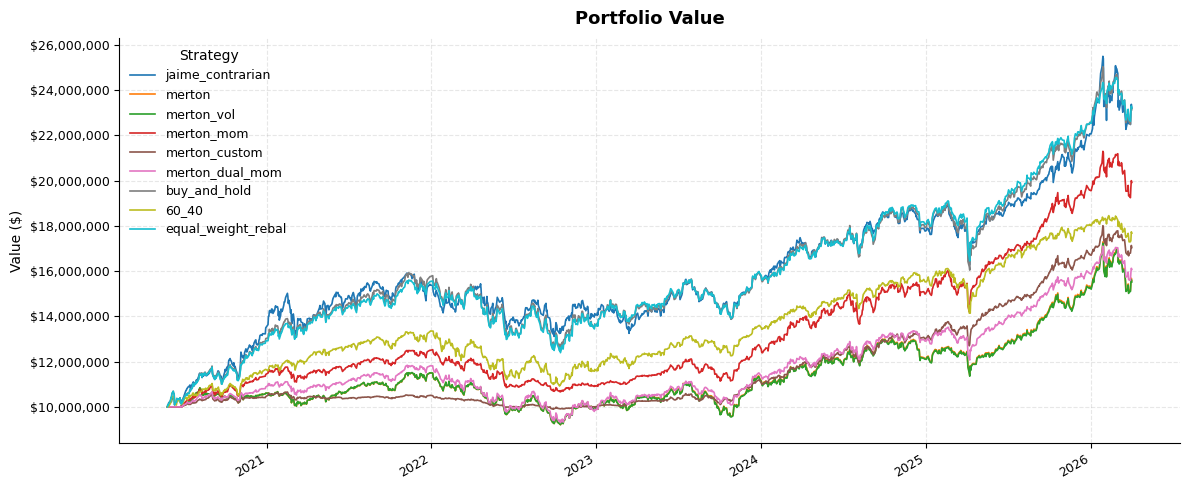

In [90]:
result.plot_value()

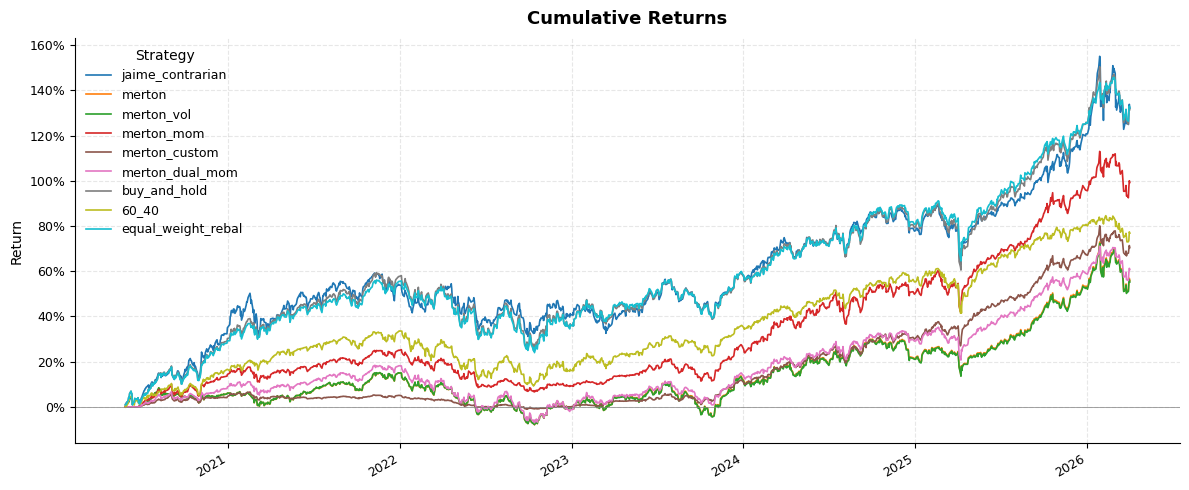

In [91]:
result.plot_returns()

/Users/hyx/miniconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


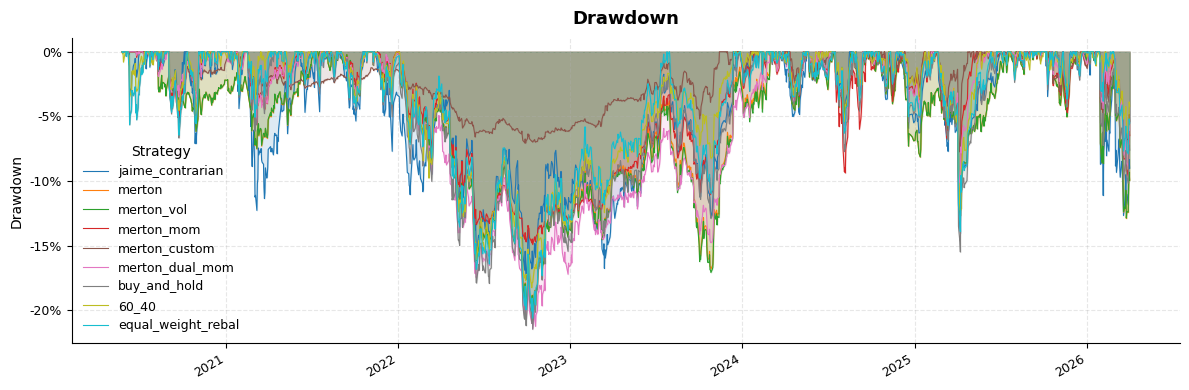

In [92]:
result.plot_drawdown()

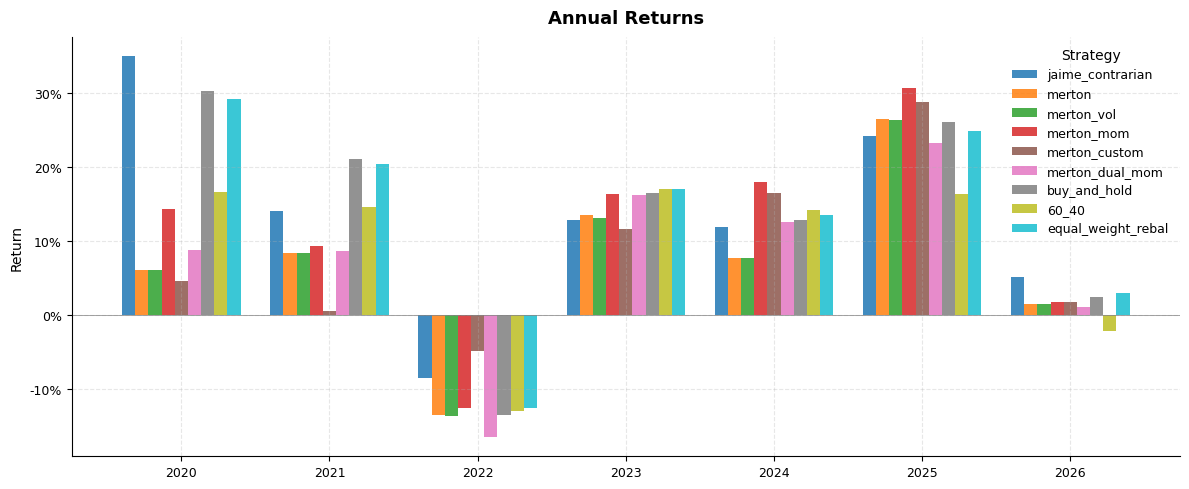

In [93]:
result.plot_annual_returns()

# 5. Métricas rolling

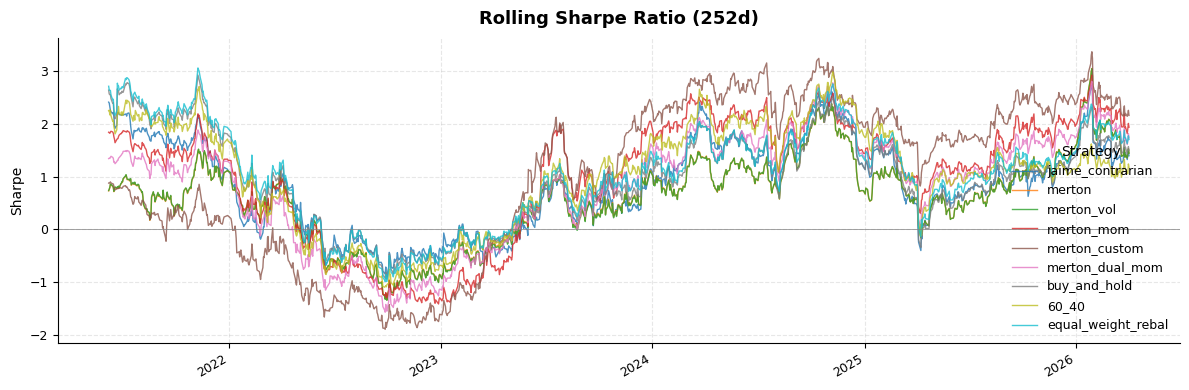

In [94]:
result.plot_rolling_sharpe()

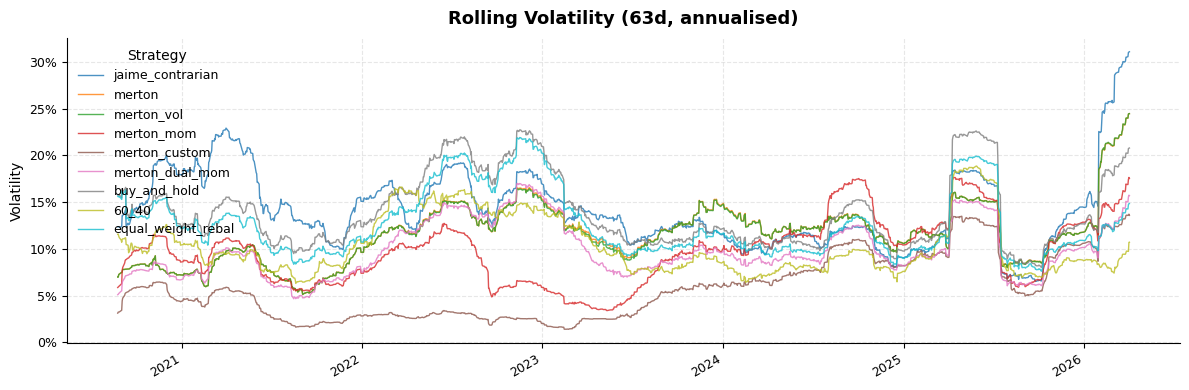

In [95]:
result.plot_rolling_volatility()

# 6. Jaime contrarian — pesos, distribución y heatmap

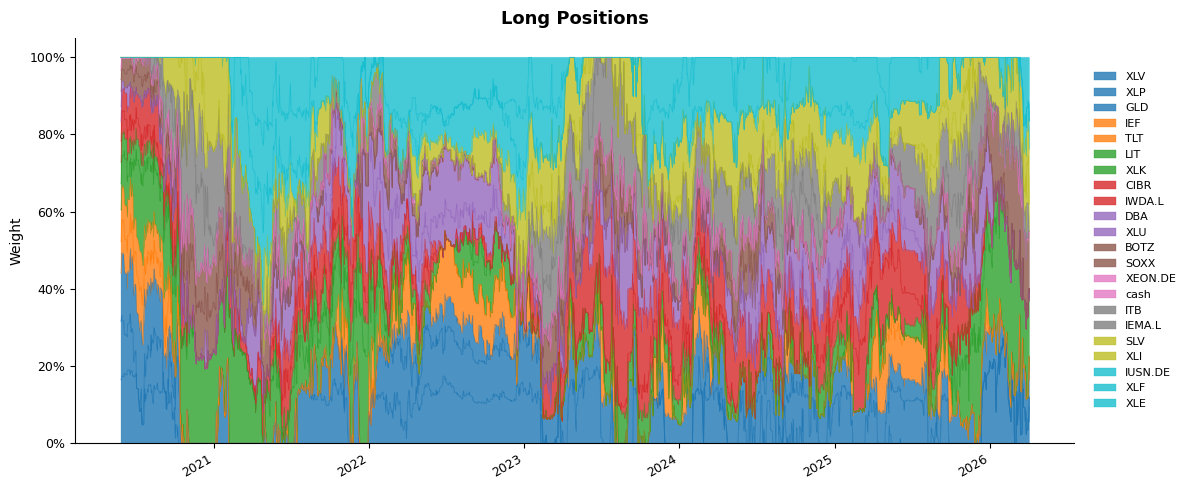

In [96]:
result.result('jaime_contrarian').plot_weights()

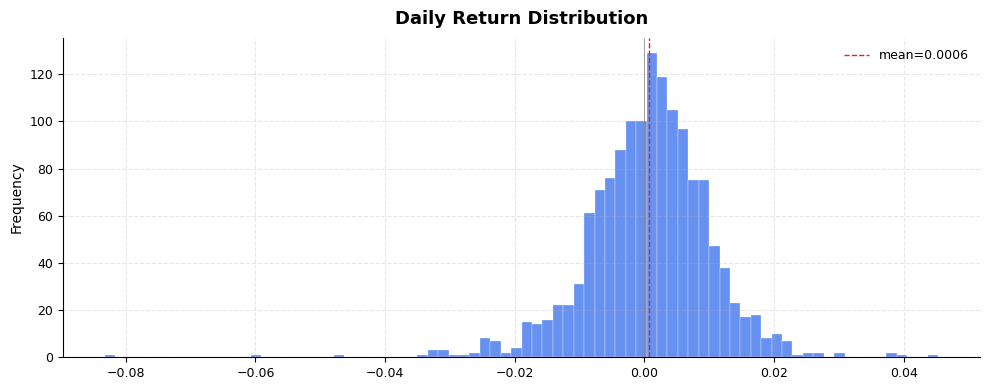

In [97]:
result.result('jaime_contrarian').plot_return_distribution()

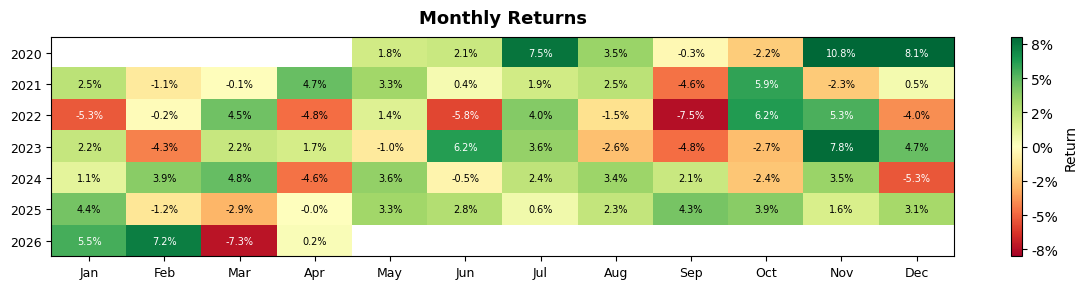

In [98]:
result.result('jaime_contrarian').plot_monthly_heatmap()

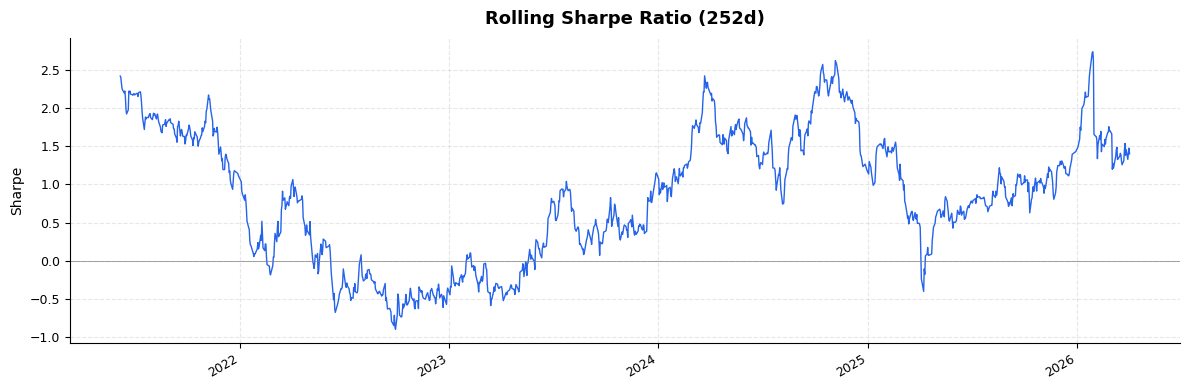

In [99]:
result.result('jaime_contrarian').plot_rolling_sharpe()

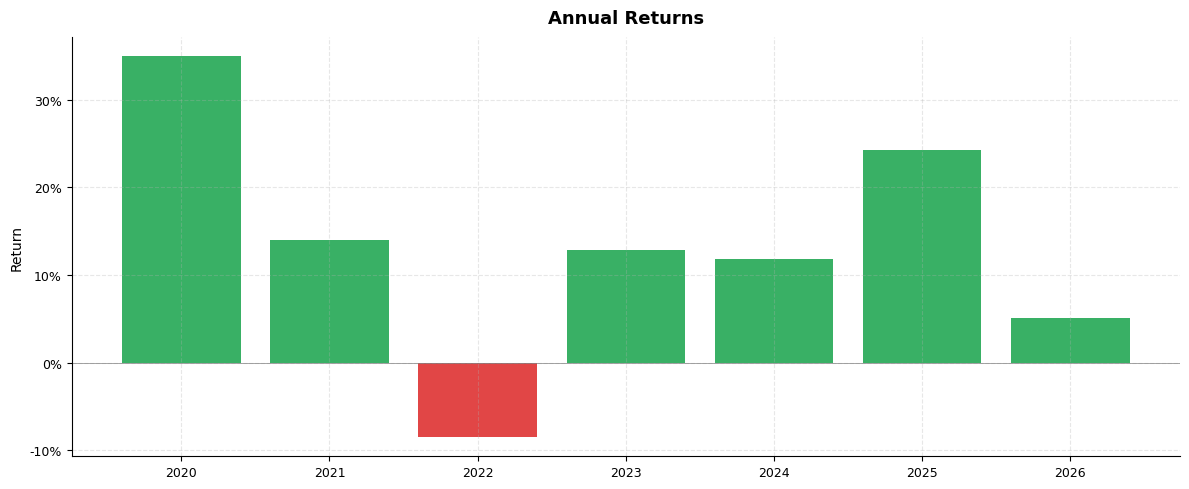

In [100]:
result.result('jaime_contrarian').plot_annual_returns()

# 7. Actividad de trading

In [101]:
for name in result.strategies:
    r = result.result(name).combined
    print(f'\n--- {name} ---')
    print(f'  Signals:  {r.total_signals}')
    print(f'  Orders:   {r.total_orders} (accepted={r.accepted_orders}, rejected={r.rejected_orders}, invalid={r.invalid_orders})')
    print(f'  Trades:   {r.total_trades}')
    print(f'  Costs:    ${r.total_costs:,.2f}')


--- jaime_contrarian ---
  Signals:  18705
  Orders:   18705 (accepted=14347, rejected=0, invalid=4358)
  Trades:   14347
  Costs:    $949,995.67

--- merton ---
  Signals:  1428
  Orders:   1428 (accepted=1049, rejected=0, invalid=379)
  Trades:   1049
  Costs:    $21,719.10

--- merton_vol ---
  Signals:  1139
  Orders:   1139 (accepted=833, rejected=0, invalid=306)
  Trades:   833
  Costs:    $20,473.72

--- merton_mom ---
  Signals:  1148
  Orders:   1148 (accepted=863, rejected=0, invalid=285)
  Trades:   863
  Costs:    $33,444.20

--- merton_custom ---
  Signals:  302
  Orders:   302 (accepted=302, rejected=0, invalid=0)
  Trades:   302
  Costs:    $16,474.80

--- merton_dual_mom ---
  Signals:  353
  Orders:   353 (accepted=272, rejected=0, invalid=81)
  Trades:   272
  Costs:    $6,835.32

--- buy_and_hold ---
  Signals:  20
  Orders:   20 (accepted=20, rejected=0, invalid=0)
  Trades:   20
  Costs:    $2,704.65

--- 60_40 ---
  Signals:  2
  Orders:   2 (accepted=2, rejected

# 8. Inspección de la estrategia Jaime

Las señales que emite Jaime llevan en el campo `info` el `regime`, `score` compuesto, `mu` estimado por BL, `r` y `raw_weight` de Merton.

In [102]:
import pandas as pd

jaime_signals = result.result('jaime_contrarian').window(0).signals_df
jaime_signals.tail(20)

,date,ticker,target_weight,reason,mu,r,score,regime,raw_weight
18685,2026-04-01,CIBR,0.000000,liquidate_excluded,NaN,NaN,NaN,NaN,NaN
18686,2026-04-01,ITB,0.000000,liquidate_excluded,NaN,NaN,NaN,NaN,NaN
18687,2026-04-01,DBA,0.000000,liquidate_excluded,NaN,NaN,NaN,NaN,NaN
18688,2026-04-01,XEON.DE,0.000000,defensive,NaN,NaN,NaN,NaN,NaN
18689,2026-04-02,IUSN.DE,0.074855,jaime_contrarian,0.025983,0.025,-0.040241,normal,0.150087
18690,2026-04-02,XLV,0.096387,jaime_contrarian,0.037505,0.025,0.033404,normal,0.194130
18691,2026-04-02,XLE,0.165026,jaime_contrarian,0.074235,0.025,0.375762,normal,0.331366
18692,2026-04-02,XLP,0.025562,jaime_contrarian,0.049483,0.025,0.019050,normal,0.052109
18693,2026-04-02,XLI,0.140855,jaime_contrarian,0.050723,0.025,0.133909,normal,0.281504
18694,2026-04-02,SOXX,0.139689,jaime_contrarian,0.113266,0.025,0.530463,normal,0.278896


In [103]:
jaime_orders = result.result('jaime_contrarian').window(0).orders_df
jaime_orders.tail(20)

,date,ticker,direction,shares,price,value,status,signal_reason,reason
18685,2026-04-01,XLI,buy,5487.783613,164.429993,9.023562e+05,accepted,jaime_contrarian,None
18686,2026-04-01,XLE,buy,4597.382826,58.970001,2.711077e+05,accepted,jaime_contrarian,None
18687,2026-04-01,GLD,buy,976.087897,437.820007,4.273508e+05,accepted,jaime_contrarian,None
18688,2026-04-01,IUSN.DE,buy,33461.773030,8.103000,2.711407e+05,accepted,jaime_contrarian,None
18689,2026-04-02,IWDA.L,sell,0.000000,0.000000,0.000000e+00,invalid,liquidate_excluded,weight unchanged
18690,2026-04-02,CIBR,sell,0.000000,0.000000,0.000000e+00,invalid,liquidate_excluded,weight unchanged
18691,2026-04-02,ITB,sell,0.000000,0.000000,0.000000e+00,invalid,liquidate_excluded,weight unchanged
18692,2026-04-02,DBA,sell,0.000000,0.000000,0.000000e+00,invalid,liquidate_excluded,weight unchanged
18693,2026-04-02,SOXX,sell,-1306.763107,339.609985,4.437898e+05,accepted,jaime_contrarian,None
18694,2026-04-02,LIT,sell,-9451.068451,74.169998,7.009857e+05,accepted,jaime_contrarian,None


In [104]:
# Distribución de regímenes a lo largo del backtest
if 'info' in jaime_signals.columns:
    regimes = jaime_signals['info'].apply(lambda d: d.get('regime') if isinstance(d, dict) else None)
    print(regimes.value_counts())
else:
    info_cols = [c for c in jaime_signals.columns if c.startswith('info_') or c == 'regime']
    print(jaime_signals[info_cols].tail() if info_cols else jaime_signals.columns.tolist())

      regime
18700    NaN
18701    NaN
18702    NaN
18703    NaN
18704    NaN


In [105]:
# Top tickers por peso medio en la cartera Jaime
jaime_snaps = result.result('jaime_contrarian').window(0).snapshots_df
weight_cols = [c for c in jaime_snaps.columns if c.endswith('_weight') and not c.startswith('cash')]
if weight_cols:
    avg = jaime_snaps[weight_cols].mean().sort_values(ascending=False).head(15)
    avg.index = [c.replace('_weight', '') for c in avg.index]
    print(avg.round(4))

XLF       0.0842
XLI       0.0836
IWDA.L    0.0833
LIT       0.0760
ITB       0.0697
XLP       0.0640
XLE       0.0577
XLV       0.0559
GLD       0.0550
XLU       0.0506
DBA       0.0489
SOXX      0.0450
IEMA.L    0.0416
IEF       0.0390
XLK       0.0372
dtype: float64


In [106]:
# Coste de transacción acumulado vs Sharpe
summary = result.summary_df[['sharpe_ratio', 'total_costs', 'annualized_return']].round(4)
summary.sort_values('sharpe_ratio', ascending=False)

,sharpe_ratio,total_costs,annualized_return
merton_custom,1.4433,16474.7965,0.0984
merton_mom,1.2330,33444.1966,0.1291
equal_weight_rebal,1.2035,13905.5671,0.1600
buy_and_hold,1.0850,2704.6470,0.1593
jaime_contrarian,1.0484,949995.6733,0.1598
60_40,0.9669,1143.9533,0.1056
merton_dual_mom,0.8407,6835.3219,0.0872
merton,0.6610,21719.1030,0.0812
merton_vol,0.6573,20473.7174,0.0805


# 9. Órdenes rechazadas (debug)

In [107]:
jaime_orders = result.result('jaime_contrarian').window(0).orders_df
rejected = jaime_orders[jaime_orders['status'] == 'rejected']
print(f'Rejected orders: {len(rejected)}')
rejected.tail(20)

Rejected orders: 0


,date,ticker,direction,shares,price,value,status,signal_reason,reason
